In this script we can make plots for:
- for one session a venn diagram of %escape, hdir and not dist to shelt
- for all sessions a bar plot of the same stuff

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]


session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [ ]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.functions.escape_utils import load, load_homing
from JR_test_scripts.escape.functions.escape_tuning_funcs import tuning_method
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.FigureSaver import Figure_Saver

import os
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from pathlib import Path
import dill as pickle
from itertools import product
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import matplotlib
from matplotlib_venn import venn3

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

In [ ]:
"""Some preset variables"""

case = 'either_tuned' # 'escape_tuned', 'dist_tuned', 'either_tuned
var = 'escape' # 'dist', 'escape'
condition = 'all' # 'shelter_only', 'barrier', 'flipped_barrier', 'all', 'barrier_both'
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/")
cond = [[0,0,1],[1,2,2]]
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
title_c_names = ['Shelter only', 'Barrier', 'Flipped barrier']
cond_colors = ['#228B22','#FF8C00','#008B8B']
tuning_data = '_25bins' # '' or '_50bins'

colors = [
    "#4363d8",  # Medium blue - different from your blues
    "#C77CFF",   # Light purple - distinct from your darker purple
    "#dcbf46"   # Gold/mustard - not used in your palette
]

In [4]:
"""Load in hdir cells"""
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

hdir_sesh = []

for idx, exp in enumerate(experiments_objects):
    session = Process(exp).load_session()
    base_path = os.path.join(session.base_path, session.processed_path)
    clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
        + "\\"
        + "good_cluster_Ids.npy"
    )

    hdir_n = hdir[session_names[idx]]
    hdir_sesh.append([int(np.where(clu_Ids == h)[0][0]) for h in hdir_n])

In [ ]:
"""Load in tuning data"""

for e, exp in enumerate(experiments_objects):
    nickname = exp.nick_name + '_' + exp.experiment_date

    # 2. load in escape homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
    data = np.load(explore_path + exp_nickname + '_Tuning' + tuning_data + '.npz')
    # identify cells that are sig tuned to %escape in homing/escape
    sig_dist = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
    
    # 2. load in escape homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
    fr_esc = data['fr_full']
    fit_real = data['y_fitted_full']
    # identify cells that are sig tuned to %escape in homing/escape
    sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
    params_esc = data['params_full']

    # 4. load in residuals data
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    data = np.load(homie_path + exp_nickname + '_ResidualsTuning' + tuning_data + '.npz')
    # find cells whose residual tuning to %escape - distance to shelter in exploration is significant
    sig_res = data['params_real_exp'][:,:,0] > np.nanpercentile(data['params_shifts_exp_res'][:,:,:,0], 95, axis = 0)

    # 5. pull out the vector of hdir cells
    hdir_cells = np.full(params_esc.shape[0], False)
    hdir_cells[hdir_sesh[e]] = True

    cells = np.full((params_esc.shape[0],4), False)
    cells[:,0] = sig_escape[:,1] # True if tuned to escape
    cells[:,1] = sig_res[:,1] # True if tuned to escape - distance to shelter
    cells[:,2] = hdir_cells # True if hdir cell
    cells[:,3] = sig_dist[:,1] # True if tuned to distance in explore

    # select which tuning curve and params to use
    params = params_esc
    fr = fr_esc

    if e == 0:
        all_params = params
        all_cells = cells
        all_fr = fr
        all_fit = fit_real
        sesh_vector = np.full(params.shape[0], e)
    else:
        all_params = np.concatenate((all_params, params), axis = 0)
        all_cells = np.concatenate((all_cells, cells), axis = 0)
        all_fr = np.concatenate((all_fr, fr), axis = 1)
        all_fit = np.concatenate((all_fit, fit_real), axis = 1)
        sesh_vector = np.concatenate((sesh_vector, np.full(params.shape[0], e)), axis = 0)

In [ ]:
"""Make a venn diagram for one session"""
s = 7
all_cells_s = all_cells[sesh_vector == s,:]
A = np.sum((all_cells_s[:,1] == True) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == False), axis = 0)  # % route only
B = np.sum((all_cells_s[:,1] == False) & (all_cells_s[:,0] == False) & (all_cells_s[:,2] == True), axis = 0)  # hdir only
C = np.sum((all_cells_s[:,1] == True) & (all_cells_s[:,0] == False) & (all_cells_s[:,2] == False), axis = 0)  # not sure what this is
AB = np.sum((all_cells_s[:,1] == False) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == True), axis = 0)  # % route and hdir
AC = np.sum((all_cells_s[:,1] == True) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == False), axis = 0)  # % route and hdir
ABC = np.sum((all_cells_s[:,1] == True) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == True), axis = 0)  # % route and hdir
BC = np.sum((all_cells_s[:,1] == False) & (all_cells_s[:,0] == False) & (all_cells_s[:,2] == True), axis = 0)  # hdir only
venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
            set_labels=(r'%escape', 'shelt_dist_explore', r'res.tuning %escape'), 
            set_colors=colors,
            alpha=0.5)

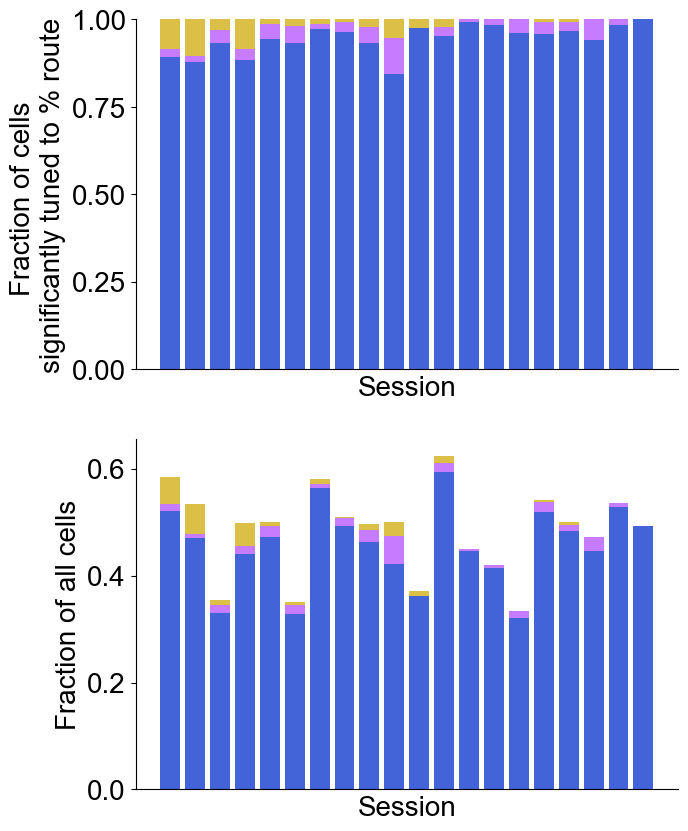

In [ ]:
"""Make a bar plot"""

fig, axs = plt.subplots(2, 1, figsize=(7, 10))

for s in np.unique(sesh_vector):
    all_cells_s = all_cells[sesh_vector == s,:]
    tot_sig = np.sum(all_cells_s[:,0], axis = 0)
    # fraction of hdir cells that are also sig tuned to escape
    frac_hdir = np.sum((all_cells_s[:,2] == True) & (all_cells_s[:,0] == True), axis = 0)
    # fraction of sig escape cells that are no longer tuned after removing dist to shelter, and are not hdir cells
    frac_dist = np.sum((all_cells_s[:,1] == False) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == False), axis = 0)
    # fraction of sig escape cells that are still tuned after removing dist to shelter, and are not hdir cells
    # frac_sig = 1 - (frac_dist + frac_hdir)
    frac_sig = np.sum((all_cells_s[:,1] == True) & (all_cells_s[:,0] == True) & (all_cells_s[:,2] == False), axis = 0)
    values = np.array([frac_sig, frac_dist, frac_hdir])
    # Plot stacked bar
    bottom_value0, bottom_value1 = 0, 0  # Start at 0
    for i in range(len(values)):
        axs[0].bar(s, values[i]/tot_sig, bottom=bottom_value0, color=colors[i])  # Single bar at x=1
        bottom_value0 += values[i]/tot_sig  # Move bottom up
        
        axs[1].bar(s, values[i]/all_cells_s.shape[0], bottom=bottom_value1, color=colors[i])  # Single bar at x=1
        bottom_value1 += values[i]/all_cells_s.shape[0]  # Move bottom up

axs[0].set_ylabel('Fraction of cells \n' + r'significantly tuned to % route')
axs[1].set_ylabel('Fraction of all cells')
for ax in axs:
    ax.set_xticks([])
    ax.set_xlabel('Session')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
figure_saver.save(fig, name_file='Sig_Cells_Fractions')